In [1]:
!pip install -q shap xgboost scikit-learn pandas matplotlib pdpbox

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from xgboost import XGBClassifier
from sklearn.inspection import PartialDependenceDisplay
import warnings
warnings.filterwarnings("ignore")

print("✅ Libraries loaded.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 44.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.3/69.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 81.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 7.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
preprocessing 0.1.13 requires nltk==3.2.4, but you have nltk 3.9.2 which is incompatible.
preprocessing 0.1.13 requires sphinx-rtd-theme==0.2.4, but you have sphinx-rtd-theme 3.0.2 which is incompatible.
✅ Libraries loaded.


In [2]:
# Path to dataset
DATA_PATH = "/kaggle/input/german-credit/german_credit_data.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (1000, 11)


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [3]:
print("Columns:", list(df.columns))
print("\nTarget column preview:")
if "Risk" in df.columns:
    print(df["Risk"].value_counts(dropna=False))
else:
    print("⚠️  Target column not found; please check column names.")


Columns: ['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk']

Target column preview:
Risk
good    700
bad     300
Name: count, dtype: int64


In [4]:
# Drop index-like column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Define target
TARGET = "Risk"

# Encode: 1 = good credit, 0 = bad credit
df[TARGET] = df[TARGET].map(lambda x: 1 if str(x).lower().strip() == "good" else 0)

# Fill missing categorical values
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET]  # remove target from cat list
num_cols = [c for c in num_cols if c != TARGET]

df[cat_cols] = df[cat_cols].fillna("unknown")

print("✅ Target encoded.\n")
print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)
print("Target distribution:\n", df[TARGET].value_counts())


✅ Target encoded.

Numeric columns: ['Age', 'Job', 'Credit amount', 'Duration']
Categorical columns: ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
Target distribution:
 Risk
1    700
0    300
Name: count, dtype: int64


In [5]:
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), cat_cols),
    ]
)

# Stratified split (keeps good/bad balance)
X = df.drop(columns=[TARGET])
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train class counts:\n", y_train.value_counts())
print("\nTest class counts:\n", y_test.value_counts())

# Build pipeline
model = Pipeline(
    steps=[
        ("pre", preprocessor),
        (
            "clf",
            XGBClassifier(
                use_label_encoder=False,
                eval_metric="logloss",
                n_estimators=200,
                max_depth=4,
                learning_rate=0.1,
                random_state=42,
            ),
        ),
    ]
)

# Train
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n✅ Model trained successfully")
print("Accuracy:", accuracy_score(y_test, y_pred))
if len(np.unique(y_test)) > 1:
    print("ROC AUC:", roc_auc_score(y_test, y_proba))
else:
    print("⚠️ ROC AUC skipped (only one class in test)")
print("\nClassification report:\n", classification_report(y_test, y_pred))


Train class counts:
 Risk
1    560
0    240
Name: count, dtype: int64

Test class counts:
 Risk
1    140
0     60
Name: count, dtype: int64

✅ Model trained successfully
Accuracy: 0.77
ROC AUC: 0.7539285714285715

Classification report:
               precision    recall  f1-score   support

           0       0.65      0.52      0.57        60
           1       0.81      0.88      0.84       140

    accuracy                           0.77       200
   macro avg       0.73      0.70      0.71       200
weighted avg       0.76      0.77      0.76       200



In [6]:
# Extract components
pre = model.named_steps["pre"]
clf = model.named_steps["clf"]

# Transform data
X_train_t = pre.transform(X_train)
X_test_t = pre.transform(X_test)

# Get feature names
num_feat_names = num_cols
cat_ohe = pre.named_transformers_["cat"]
try:
    ohe_feature_names = list(cat_ohe.get_feature_names_out(cat_cols))
except:
    ohe_feature_names = []
    for i, c in enumerate(cat_cols):
        ohe_feature_names += [f"{c}_{v}" for v in cat_ohe.categories_[i]]

feature_names = num_feat_names + ohe_feature_names
print(f"✅ Feature matrix ready ({len(feature_names)} features).")


✅ Feature matrix ready (26 features).


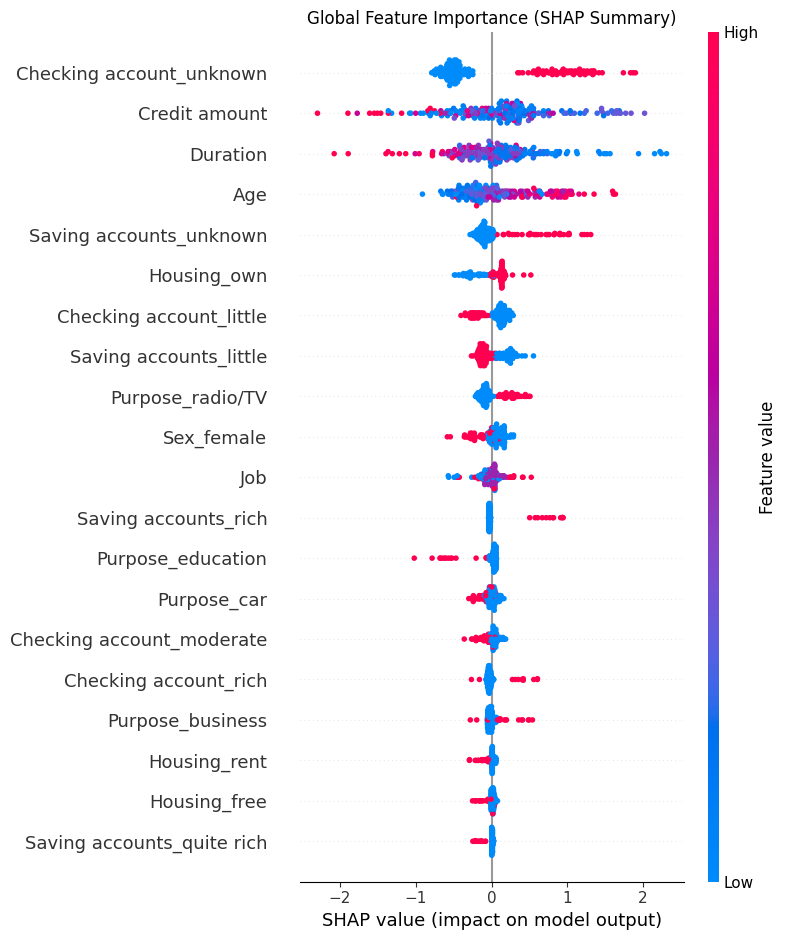

In [7]:
# Initialize SHAP explainer for XGBoost
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_t)

plt.title("Global Feature Importance (SHAP Summary)")
shap.summary_plot(shap_values, X_test_t, feature_names=feature_names, show=True)


Applicant index: 5
True label (1=good,0=bad): 1
Predicted good-credit probability: 0.8582114


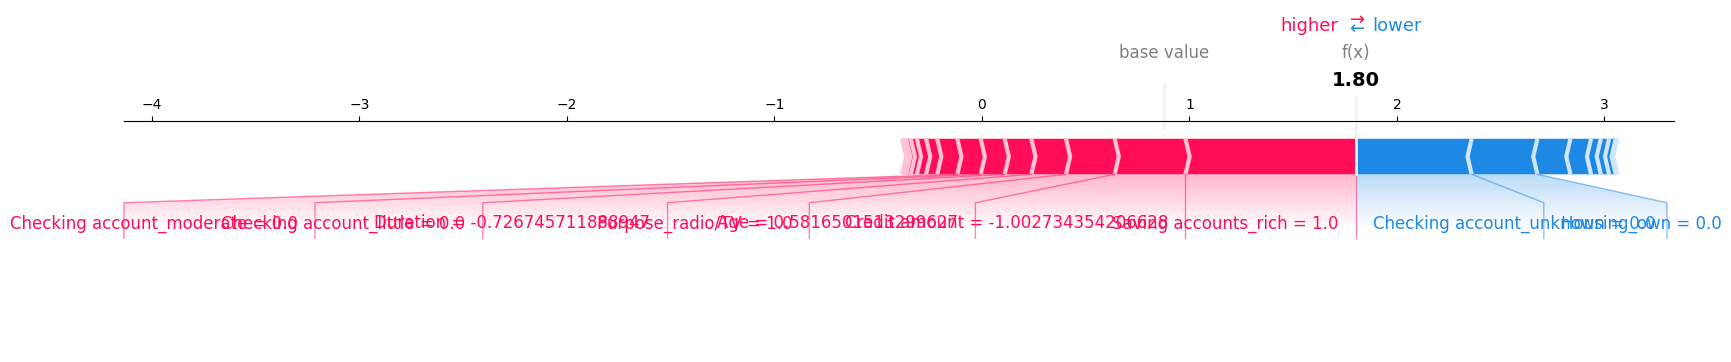

In [8]:
# Picking one example to explain
idx = 5
print("Applicant index:", idx)
print("True label (1=good,0=bad):", y_test.iloc[idx])
print("Predicted good-credit probability:", model.predict_proba(X_test.iloc[[idx]])[0,1])

# Local explanation
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[idx, :],
    X_test_t[idx, :],
    feature_names=feature_names,
    matplotlib=True
)


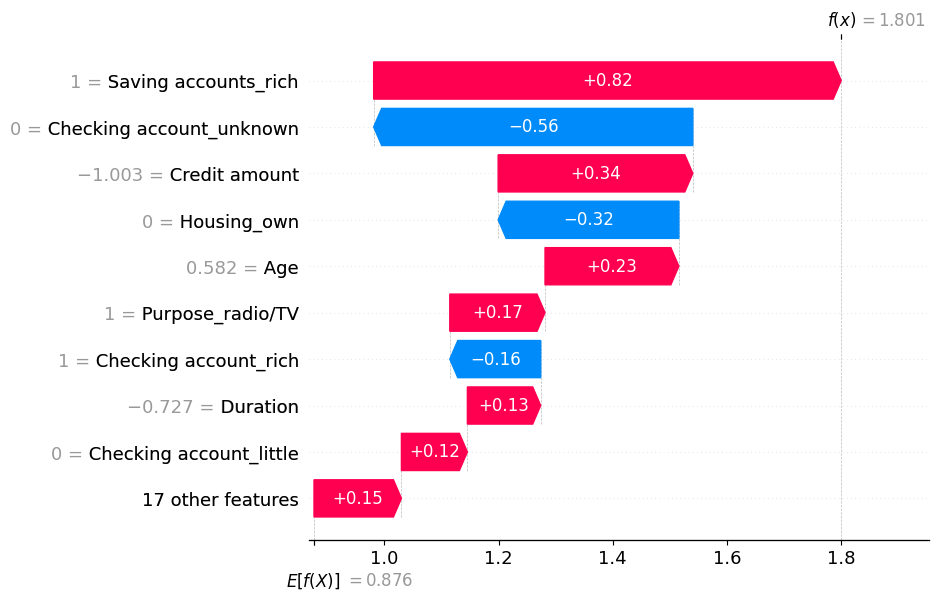

In [10]:
# SHAP Waterfall Plot for a single applicant (index = idx)

shap_exp = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test_t[idx],
    feature_names=feature_names
)

shap.plots.waterfall(shap_exp)


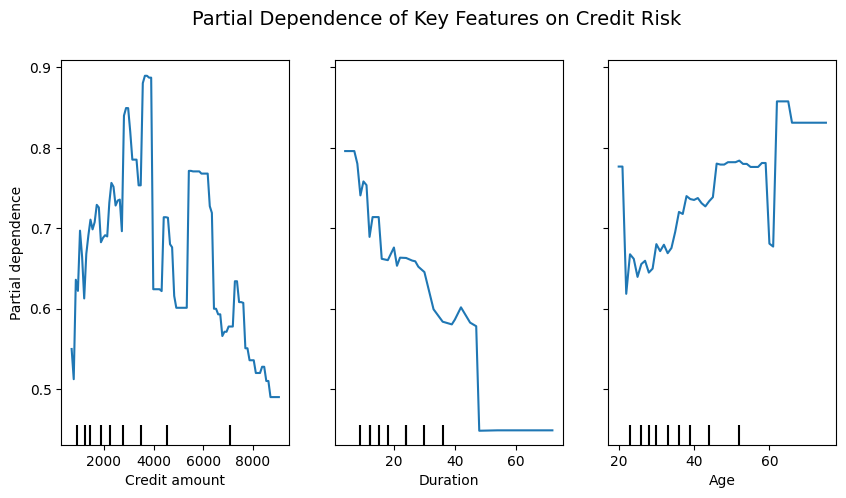

In [11]:
# Choose top numeric features for PDP
pdp_features = [f for f in ["Credit amount", "Duration", "Age"] if f in num_cols]

if pdp_features:
    fig, ax = plt.subplots(figsize=(10, 5))
    PartialDependenceDisplay.from_estimator(
        model, X_train, pdp_features, kind="average", ax=ax
    )
    plt.suptitle("Partial Dependence of Key Features on Credit Risk", fontsize=14)
    plt.show()
else:
    print("No matching numeric columns found for PDP.")


In [12]:
print("Model-Agnostic XAI in Finance completed successfully!")


Model-Agnostic XAI in Finance completed successfully!
